In [1]:
using Pkg
Pkg.activate("./../julia-code")

  Activating project at `~/code/compositional/julia-code`


In [2]:
using Meris
using DataFrames, DataFramesMeta, StatsBase, Distributions, LsqFit
using CairoMakie, MakiePublication, LaTeXStrings

In [3]:
# import dataset
arXiv_df =  Meris.arXivSampler.collect_arXive(stopwords=true);
# bci_df = Meris.BCITreeSampler.load_treedata(; joinquadrats=true, steps=1);
# lego_df = Meris.LegoSampler.parse_themes(; returnthemes=false);

In [4]:
first(arXiv_df, 5)

Row,domain,topic,component_id,sample_id,counts,nreads
,String,String,String,Int64,Int64,Int64
1,physics,soc-ph,bodrum,1,1,2586
2,physics,soc-ph,whose,1,1,2586
3,physics,soc-ph,favor,1,2,2586
4,physics,soc-ph,sp,1,4,2586
5,physics,soc-ph,bronzezeit,1,1,2586


### HYP1: Component's distribution is power-law within a document
If this is true, it may indicate that generation of a single document is done through a Pitman-Yor process.

### HYP2: Heap's law is satisfied for a set of documents of the same type
If it is true then the generating process might be the Pitman-Yor or the Gerlach process. In particular, if Heap's law is found to hold with double scaling then the simple Pitman_Yor is excluded.

In [6]:
sdf = @chain arXiv_df begin
    @groupby(:sample_id, :domain, :topic)
    @combine(
        :vocab_size = length(unique(:component_id)),
        :nreads = :nreads
    )
end

sdf = unique(sdf)
sdf = sdf[sdf.vocab_size .> 1, :];

In [7]:
x, y = log10.(sdf.nreads), log10.(sdf.vocab_size)

model(x, p) = [xi < p[3] ? p[1] + xi : p[1] + p[3] * (1 - p[2]) + xi * p[2] for xi in x]
p0 = [1.0, 1.0, log10(500.0)]
fit = curve_fit(model, x, y, p0)
p = coef(fit)

println("Fitted parameters: ", p)

Fitted parameters: [0.552364011445637, 0.6331215443485244, 0.29629751279809835]


In [11]:
10 .^ model(p[3], p)

7.0576728655277

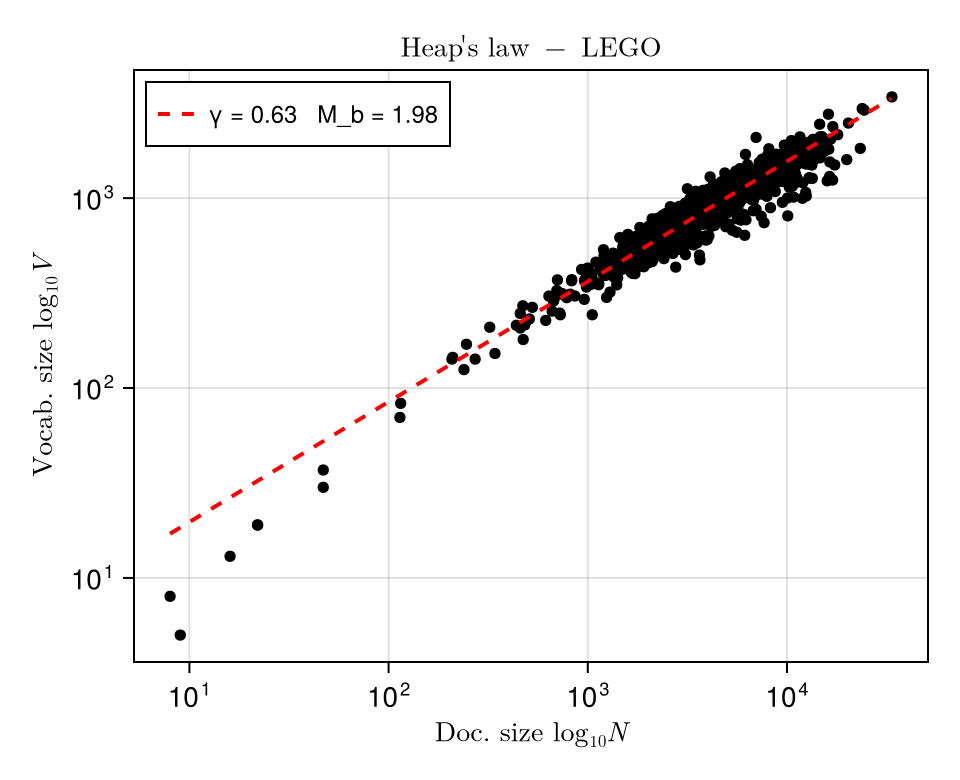

In [8]:
fig = Figure(size=(320*1.5, 260*1.5))
ax = Axis(fig[1,1],
    xscale=log10, yscale=log10,
    title=L"\text{Heap's law - LEGO}",
    xlabel=L"\text{Doc. size } \log_{10}N",
    ylabel=L"\text{Vocab. size } \log_{10}V"    
)

scatter!(ax, 10 .^ (x), 10 .^ (y), color=:black, markersize=8)

xrange = minimum(x):1e-2:maximum(x)
lines!(ax, 10 .^ (xrange), 10 .^ (model(xrange, p)), color=:red, linestyle=:dash, label="γ = $(round(p[2], digits=2))   M_b = $(round(10 ^ p[3], digits=2))", linewidth=2)

axislegend(ax, position=:lt, framevisible=true, labelsize=12, markersize=8)
fig

In [143]:
savefig("Heap.png", fig)

In [55]:
1/1.77

0.5649717514124294

### HYP3: The distribution of document sizes is heavy-tailed but with an upper cutoff
Not sure on the relevance of this. Supposition: this distribution introduces some sort of cutoff which yeald the AFD to be a Tweedie distribution for which TL is guaranteed

### HYP4: Taylor's law is satisfied for components within a set of documents
Similarly to Heap's law, TL is found to hold in most complex systems. But is it holding because of HYP1 and/or HYP2? Or is it uncorrelated from them? Also, TL is a very robust pattern and it may indicate that the AFD is a Tweedie distribution, although it is not guaranteed.

In [4]:
df = deepcopy(arXive_df)
df.class .= arXive_df.domain .* "/" .* arXive_df.topic
Meris.DataTools.df_filter!(df; min_samples=20, min_nreads=2000)
TL_df = Meris.Taylor.compute(df, :component_id, minoccupancy=0.99)
first(TL_df, 5)

LoadError: UndefVarError: `arXive_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [5]:
df = deepcopy(arXive_df)
df.class .= arXive_df.domain .* "/" .* arXive_df.topic
Meris.DataTools.df_filter!(df; min_samples=20, min_nreads=2000)

classes = unique(df.class)
mean_var_dict = Dict()
for class in classes
    mat = Meris.DataTools.get_frequencies(df[df.class .== class, :]; occ=0.2, rescale=false)
    mean_var_dict[class] = Dict()
    mean_var_dict[class]["mean"] = mean(mat, dims=1)
    mean_var_dict[class]["var"] = var(mat, dims=1)
    mean_var_dict[class]["occ"] = [sum(col .!= 0) / length(col) for col in eachcol(mat)]
end

In [6]:
# Linear model to fit
model(t, p) = p[1] .+ p[2] .* t

# Dictionaries to store fit params and scores
lsq_params = Dict()
york_params = Dict()

for e in classes
    println("--- $e ---")
    
    # Data for this class
    x, y = [log.(mean_var_dict[e]["mean"])...], [log.(mean_var_dict[e]["var"])...]
    occ = [mean_var_dict[e]["occ"]...]

    # Fit a straight line using LsqFit
    p0 = [0.5, 0.5]
    mfit = curve_fit(model, x, y, p0)
    p = mfit.param
    cov = estimate_covar(mfit)
    lsq_params[e] = Dict(:a => p[1], :b => p[2], :σa => sqrt(cov[1,1]), :σb => sqrt(cov[2,2]), :scores => Meris.GOF.fit_scores(model, x, y, p))
    println("LsqFit")
    println("\t a: $(round(p[1], digits=4)) +- $(round(sqrt(cov[1,1]), digits=4)) \n\t b: $(round(p[2], digits=4)) +- $(round(sqrt(cov[2,2]), digits=4)) \n\t R2: $(lsq_params[e][:scores][:R2])")

    # Fit a straight line using York method
    a, b, σa, σb = Meris.StraightLine.weightedyorkfit(x, y, occ, occ)
    york_params[e] = Dict(:a => a, :b => b, :σa => σa, :σb => σb, :scores => Meris.GOF.fit_scores(model, x, y, [a, b]))
    println("YorkFit")
    println("\t a: $(round(a, digits=4)) +- $(round(σa, digits=4)) \n\t b: $(round(b, digits=4)) +- $(round(σb, digits=4)) \n\t R2: $(york_params[e][:scores][:R2])")
    println()
end

# As a GOF score we use the Coefficient of Determination R2
# R2 = 1 indicates a perfect fit
# R2 = 0 means that the model is just as informative as considering the mean of the data
# R2 < 0 indicates a poor fit

--- physics/soc-ph ---
LsqFit
	 a: -1.8895 +- 0.1825 
	 b: 1.6222 +- 0.0216 
	 R2: 0.840867324809915
YorkFit
	 a: -1.0883 +- 0.9201 
	 b: 1.7368 +- 0.1127 
	 R2: 0.8239488700893658

--- physics/plasm-ph ---
LsqFit
	 a: -1.4884 +- 0.191 
	 b: 1.6674 +- 0.0233 
	 R2: 0.8507384898038277
YorkFit
	 a: -0.6387 +- 0.9856 
	 b: 1.7918 +- 0.1246 
	 R2: 0.8338461501270664

--- physics/ao-ph ---
LsqFit
	 a: -1.1347 +- 0.1753 
	 b: 1.7135 +- 0.0206 
	 R2: 0.8539287051831277
YorkFit
	 a: -0.2929 +- 0.8817 
	 b: 1.8356 +- 0.1073 
	 R2: 0.8354222630107548

--- physics/acc-ph ---
LsqFit
	 a: -1.2111 +- 0.1507 
	 b: 1.7062 +- 0.0176 
	 R2: 0.8763651468600331
YorkFit
	 a: -0.5337 +- 0.7884 
	 b: 1.8058 +- 0.0955 
	 R2: 0.8627574155864184

--- math/CT ---
LsqFit
	 a: -1.875 +- 0.1539 
	 b: 1.6599 +- 0.0178 
	 R2: 0.8849550214351797
YorkFit
	 a: -1.3924 +- 0.6699 
	 b: 1.7387 +- 0.0812 
	 R2: 0.8726262666930966

--- astro-ph/CO ---
LsqFit
	 a: -1.4854 +- 0.1496 
	 b: 1.6677 +- 0.0171 
	 R2: 0.859707440677

### HYP5: AFD (for a single species) follows a distribution in the Pareto family
The idea is that between some lower and upper thresholds, all species follow the same type of distribution

### HYP6: Aggregated AFD is of the same family of the single species AFD
This is true only if the shape parameters of the single species AFD are very similar, if not the same.

In [7]:
df = deepcopy(arXive_df)
df.class .= arXive_df.domain .* "/" .* arXive_df.topic
Meris.DataTools.df_filter!(df; min_samples=20, min_nreads=2000)

classes = unique(df.class)
mean_var_dict = Dict()
for class in classes
    mat = Meris.DataTools.get_frequencies(df[df.class .== class, :]; occ=0.2, rescale=false)
    mean_var_dict[class] = Dict()
    mean_var_dict[class]["mean"] = mean(mat, dims=1)
    mean_var_dict[class]["var"] = var(mat, dims=1)
    mean_var_dict[class]["occ"] = [sum(col .!= 0) / length(col) for col in eachcol(mat)]
end

In [8]:
# Linear model to fit
model(t, p) = p[1] .+ p[2] .* t

# Dictionaries to store fit params and scores
lsq_params = Dict()
york_params = Dict()

for e in classes
    println("--- $e ---")
    
    # Data for this class
    x, y = [log.(mean_var_dict[e]["mean"])...], [log.(mean_var_dict[e]["var"])...]
    occ = [mean_var_dict[e]["occ"]...]

    # Fit a straight line using LsqFit
    p0 = [0.5, 0.5]
    mfit = curve_fit(model, x, y, p0)
    p = mfit.param
    cov = estimate_covar(mfit)
    lsq_params[e] = Dict(:a => p[1], :b => p[2], :σa => sqrt(cov[1,1]), :σb => sqrt(cov[2,2]), :scores => Meris.GOF.fit_scores(model, x, y, p))
    println("LsqFit")
    println("\t σ2_mle: $(lsq_params[e][:scores][:σ2_mle])")

    # Fit a straight line using York method
    a, b, σa, σb = Meris.StraightLine.weightedyorkfit(x, y, occ, occ)
    york_params[e] = Dict(:a => a, :b => b, :σa => σa, :σb => σb, :scores => Meris.GOF.fit_scores(model, x, y, [a, b]))
    println("YorkFit")
    println("\t σ2_mle: $(york_params[e][:scores][:σ2_mle])")
    println()
end

# We consider the variance of residuals 'σ2_mle' as a measure of how spread the shape parameters are.
# A high spread would indicate that the aggregated AFD is not reflecting the nature of the specieswise AFD
# since it would be a mixture of distributions of different shapes.

--- physics/soc-ph ---
LsqFit
	 σ2_mle: 0.3373601544230951
YorkFit
	 σ2_mle: 0.3732271596770873

--- physics/plasm-ph ---
LsqFit
	 σ2_mle: 0.33816305389297296
YorkFit
	 σ2_mle: 0.3764339059363654

--- physics/ao-ph ---
LsqFit
	 σ2_mle: 0.3854519165098006
YorkFit
	 σ2_mle: 0.4342865873605103

--- physics/acc-ph ---
LsqFit
	 σ2_mle: 0.3491598834542001
YorkFit
	 σ2_mle: 0.38758977393332317

--- math/CT ---
LsqFit
	 σ2_mle: 0.4135586645417449
YorkFit
	 σ2_mle: 0.45787753365019407

--- astro-ph/CO ---
LsqFit
	 σ2_mle: 0.38955561239158965
YorkFit
	 σ2_mle: 0.43936231614672394

--- astro-ph/EP ---
LsqFit
	 σ2_mle: 0.3923596769739083
YorkFit
	 σ2_mle: 0.44286129382201544

--- astro-ph/SR ---
LsqFit
	 σ2_mle: 0.4018962103713021
YorkFit
	 σ2_mle: 0.4555355124209536

--- astro-ph/GA ---
LsqFit
	 σ2_mle: 0.40801962916325496
YorkFit
	 σ2_mle: 0.46514102047007316

--- q-bio/PE ---
LsqFit
	 σ2_mle: 0.3670472433557609
YorkFit
	 σ2_mle: 0.4097349078054097

--- q-bio/NC ---
LsqFit
	 σ2_mle: 0.3782715636